In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# df = pd.read_csv(r'C:\Users\Owner\Zeely_data_update202605251615.csv')
# print(df.shape)
# df.head(5)

In [3]:
df1 = pd.read_csv(r'C:\Users\Owner\Downloads\Psyfint_new\Data\ZMS_HUR_data202606081515_v3.csv')
print(df1.shape)
df1.head(5)


(58658, 86)


,cust_code,actor_id,gender,birth_date,age,city_name,scr_id,scr_calc_at,first_open_date,hashur,...,avlaga_cnt,adv_date_range_days,avg_days_between_loans,days_since_last_loan,first_loan_date,last_loan_date,open_arr_cnt,ever_overdue_ratio,has_dpd_12m,zms_monthly_payment
0,1020000004,5,1,1995-11-15,29,ОРХОН-TOTAL,8999dfe4-85a7-4333-a78f-1b0c2ce633d2,2025-09-30 15:39:58.825,2025-10-01,0,...,0.0,2620.0,873.0,70.0,2018-05-20,2025-07-22,0.0,0.0,0.0,354145.98
1,1020000036,37,0,1981-06-13,44,УЛААНБААТАР-ХАН-УУЛ,cda9b2d5-eeec-487d-8abe-52c3ab1bc646,2026-04-02 19:08:18.568,2026-04-02,0,...,0.0,1931.0,83.0,30.0,2020-11-18,2026-03-03,0.0,0.0,0.0,143019.68
2,1020000113,114,1,1996-04-01,29,УЛААНБААТАР-БАЯНЗҮРХ,270d8271-98af-4e79-856f-3168de5271d8,2025-09-16 14:11:56.451,2025-09-16,1,...,1.0,1783.0,61.0,239.0,2020-03-04,2025-01-20,0.0,0.0,0.0,1586907.83
3,1020000247,248,1,1998-12-01,26,БУЛГАН-TOTAL,8c6d712f-0b9f-40ac-811b-c7edde48516d,2025-10-08 21:08:53.274,2025-10-08,1,...,1.0,2456.0,74.0,8.0,2019-01-09,2025-09-30,0.0,0.0,0.0,2252686.58
4,1020000250,251,0,2000-02-14,25,УЛААНБААТАР-СОНГИНОХАЙРХАН 4-Р ХОРОО,6541abf7-a442-4a75-8f2a-a7fd2f013a60,2025-10-11 21:30:21.600,2025-10-12,1,...,1.0,2514.0,81.0,3.0,2018-11-20,2025-10-08,0.0,0.0,0.0,3923783.25


In [4]:
df1['first_open_date'] = pd.to_datetime(df1['first_open_date'])
df1['scr_calc_at'] = pd.to_datetime(df1['scr_calc_at'])

df1 = df1[(df1['first_open_date'] - df1['scr_calc_at']).dt.days <= 90]
df1.shape

(57127, 86)

In [5]:
# df1 = df1[df1['ln_utilization_ratio'] <= 1]
# df1.shape

In [6]:
col_index = df1.columns.get_loc('current_org_name') + 1

df1.insert(
    col_index,
    'is_sain_dur',
    (
        df1['salary_last_amt'].notna() &
        df1['current_org_name'].str.upper().str.contains(
            'САЙН ДУРЫН',
            na=False
        )
    ).astype(int)
)
drop_cols = ['current_org_name', 'birth_date', 'first_open_date', 'scr_calc_at']
df1.drop(columns=drop_cols, inplace=True)

In [7]:
#Цалин 
df1.loc[
    df1['salary_last_amt'].isna() &
    (
        df1['salary_avg_3m'].notna() |
        df1['salary_avg_6m'].notna() |
        df1['salary_avg_24m'].notna()
    ),
    'salary_last_amt'
] = 0
df1.loc[
    df1['salary_min_6m'].isna() &
    (
        df1['salary_avg_3m'].notna() |
        df1['salary_avg_6m'].notna() |
        df1['salary_avg_24m'].notna()
    ),
    'salary_min_6m'
] = 0
df1.loc[
    df1['salary_max_6m'].isna() &
    (
        df1['salary_avg_3m'].notna() |
        df1['salary_avg_6m'].notna() |
        df1['salary_avg_24m'].notna()
    ),
    'salary_max_6m'
] = 0
df1.loc[
    df1['current_org_cont_months'].isna() & df1['salary_last_amt'].notna(),
    'current_org_cont_months'
] = 0
df1.loc[
    df1['salary_cv_6m'].isna() & (df1['salary_avg_6m'] == 0),
    'salary_cv_6m'
] = -1
df1.loc[
    df1['salary_growth_3m_vs_6m'].isna() & ((df1['salary_avg_6m'] == 0)|(df1['salary_avg_3m'] == 0)),
    'salary_growth_3m_vs_6m'
] = -1
df1.loc[
    df1['salary_growth_3m_vs_prev3m'].isna() & ((df1['salary_avg_prev3m'] == 0)|(df1['salary_avg_3m'] == 0)),
    'salary_growth_3m_vs_prev3m'
] = -1

In [8]:
# зээл төлөвтэй 
df1.loc[
    df1['ln_closed_total_amt'].isna() & (df1['ln_clsd_ln_cnt'] == 0),
    'ln_closed_total_amt'
] = 0
df1.loc[
    df1['ln_open_total_balance'].isna() & (df1['ln_open_ln_cnt'] == 0),
    'ln_open_total_balance'
] = 0
df1.loc[
    df1['ln_max_loan_concentration'].isna() & 
    ((df1['ln_closed_total_amt'] == 0) | (df1['ln_ln_cnt'] == 0)),
    'ln_max_loan_concentration'
] = 0
df1.loc[
    df1['ln_avg_loan_amt'].isna() & (df1['ln_ln_cnt'] == 0),
    'ln_avg_loan_amt'
] = 0
df1.loc[
    df1['ln_min_adv_amt'].isna() & (df1['ln_ln_cnt'] == 0),
    'ln_min_adv_amt'
] = 0
df1.loc[
    df1['ln_max_term_days'].isna() & (df1['ln_ln_cnt'] == 0),
    'ln_max_term_days'
] = 0
df1.loc[
    df1['ln_short_term_loan_ratio'].isna() & (df1['ln_ln_cnt'] == 0),
    'ln_short_term_loan_ratio'
] = 0

df1.loc[
    df1['ln_early_payoff_ratio'].isna() & 
    ((df1['ln_ln_cnt'] == 0)| (df1['ln_clsd_ln_cnt'] == 0)),
    'ln_early_payoff_ratio'
] = 0
df1.loc[
    df1['ln_utilization_ratio'].isna() & 
    ((df1['ln_ln_cnt'] == 0)| (df1['ln_open_total_balance'] == 0)),
    'ln_utilization_ratio'
] = 0
df1.loc[
    df1['ln_avg_term_days'].isna() & (df1['ln_ln_cnt'] == 0),
    'ln_avg_term_days'
] = 0



In [9]:
# Зээлийн шугам төлөвтэй 
df1.loc[
    df1['line_total_amt'].isna() & (df1['line_cnt'] == 0),
    'line_total_amt'
] = 0
df1.loc[
    df1['line_total_balance'].isna() & (df1['line_cnt'] == 0),
    'line_total_balance'
] = 0

df1.loc[
    df1['line_min_adv_amt'].isna() & (df1['line_cnt'] == 0),
    'line_min_adv_amt'
] = 0
df1.loc[
    df1['line_max_adv_amt'].isna() & (df1['line_cnt'] == 0),
    'line_max_adv_amt'
] = 0
df1.loc[
    df1['line_utilization_ratio'].isna() & 
    ((df1['line_cnt'] == 0)| (df1['line_total_balance'] == 0)),
    'line_utilization_ratio'
] = 0

df1.loc[
    df1['line_early_payoff_ratio'].isna() & 
    ((df1['line_cnt'] == 0)| (df1['line_closed_ln_cnt'] == 0)),
    'line_early_payoff_ratio'
] = 0
df1.loc[
    df1['avg_days_between_loans'].isna() & (df1['adv_date_range_days'] == 0),
    'avg_days_between_loans'
] = 0


In [10]:
# df1.to_csv(r'C:\Users\Owner\ZMS_HUR_data202606031546_v2.csv', index=False)

---
## Хувьсагчийн Цогц Шинжилгээ
### 1. Тоон хувьсагчдын үндсэн статистик + Тархалт

In [11]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Хувьсагчдыг ангилах
target_cols = ['15+', '30+', 'before_first_close_30+']
excl_cols   = ['cust_code', 'actor_id', 'scr_id', 'gender', 'city_name',
               'hashur', 'haszms', 'first_loan_date', 'last_loan_date', 'is_sain_dur']
num_cols = [c for c in df1.select_dtypes(include='number').columns
            if c not in target_cols + excl_cols]

# Үндсэн статистик + хоосон утгын хувь
desc = df1[num_cols].describe().T.round(3)
desc.insert(0, 'missing_%', (df1[num_cols].isna().sum() / len(df1) * 100).round(2))
display(desc)

,missing_%,count,mean,std,min,25%,50%,75%,max
age,0.00,57127.0,28.175,10.373,18.00,19.000,25.000,35.000,89.00
salary_last_amt,51.59,27655.0,1677579.346,1814044.881,0.00,0.000,1372950.790,2562091.240,40688928.00
salary_avg_3m,51.59,27655.0,1675226.635,1688420.208,0.00,264000.000,1366666.670,2572634.255,38195952.00
salary_avg_prev3m,51.59,27655.0,1543609.213,1610045.407,0.00,0.000,1164059.670,2449490.835,28249984.00
salary_avg_6m,51.59,27655.0,1609417.924,1589160.731,0.00,328968.775,1270182.500,2485844.400,31277950.50
...,...,...,...,...,...,...,...,...,...
days_since_last_loan,31.49,39136.0,202.839,366.027,-86.00,14.000,63.000,225.000,9206.00
open_arr_cnt,31.49,39136.0,0.010,0.263,0.00,0.000,0.000,0.000,28.00
ever_overdue_ratio,31.49,39136.0,0.003,0.052,0.00,0.000,0.000,0.000,1.00
has_dpd_12m,31.49,39136.0,0.006,0.077,0.00,0.000,0.000,0.000,1.00


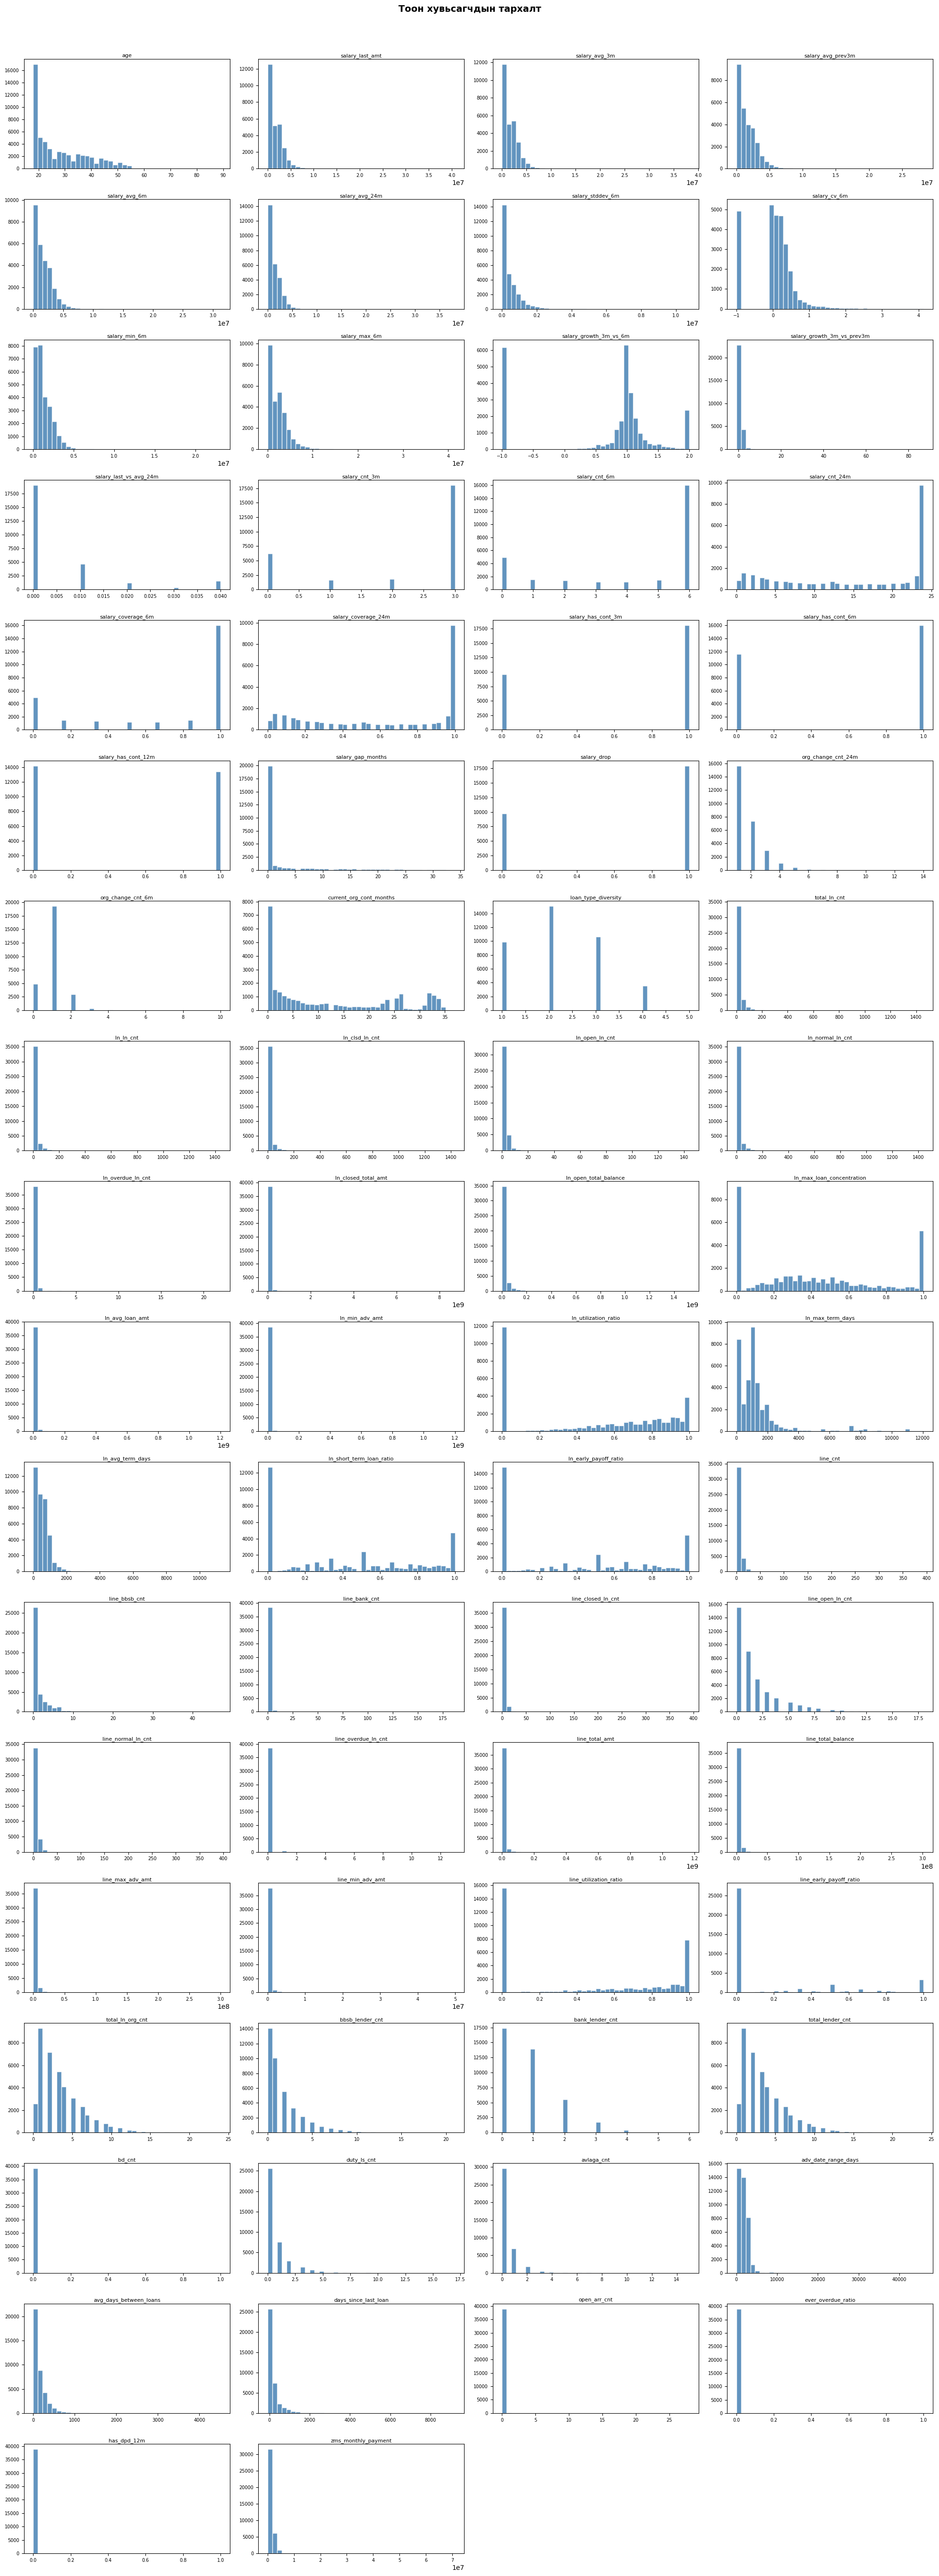

In [12]:
n_cols_plot = 4
n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, n_rows_plot * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    data = df1[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=8, pad=3)
    axes[i].tick_params(labelsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Тоон хувьсагчдын тархалт', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

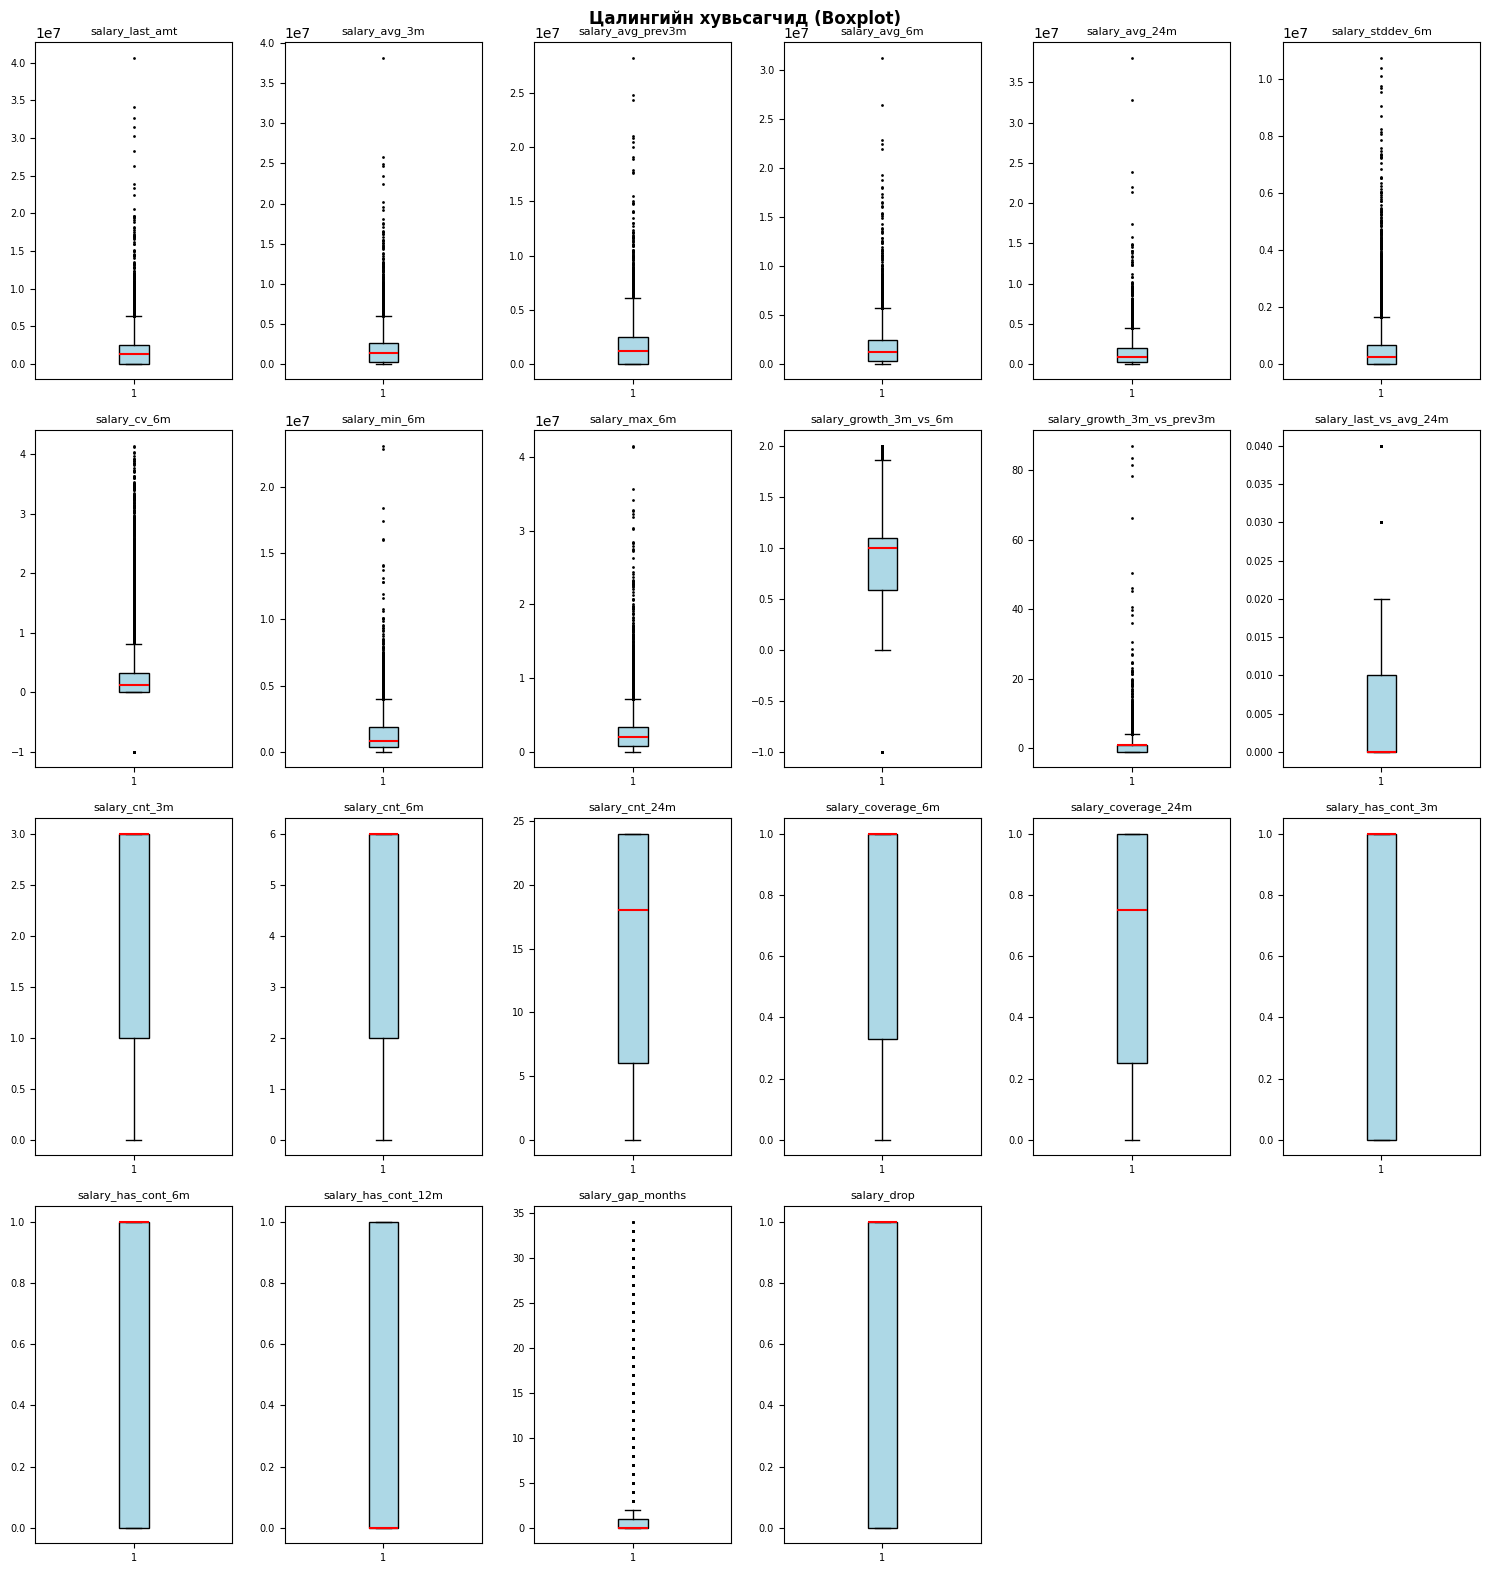

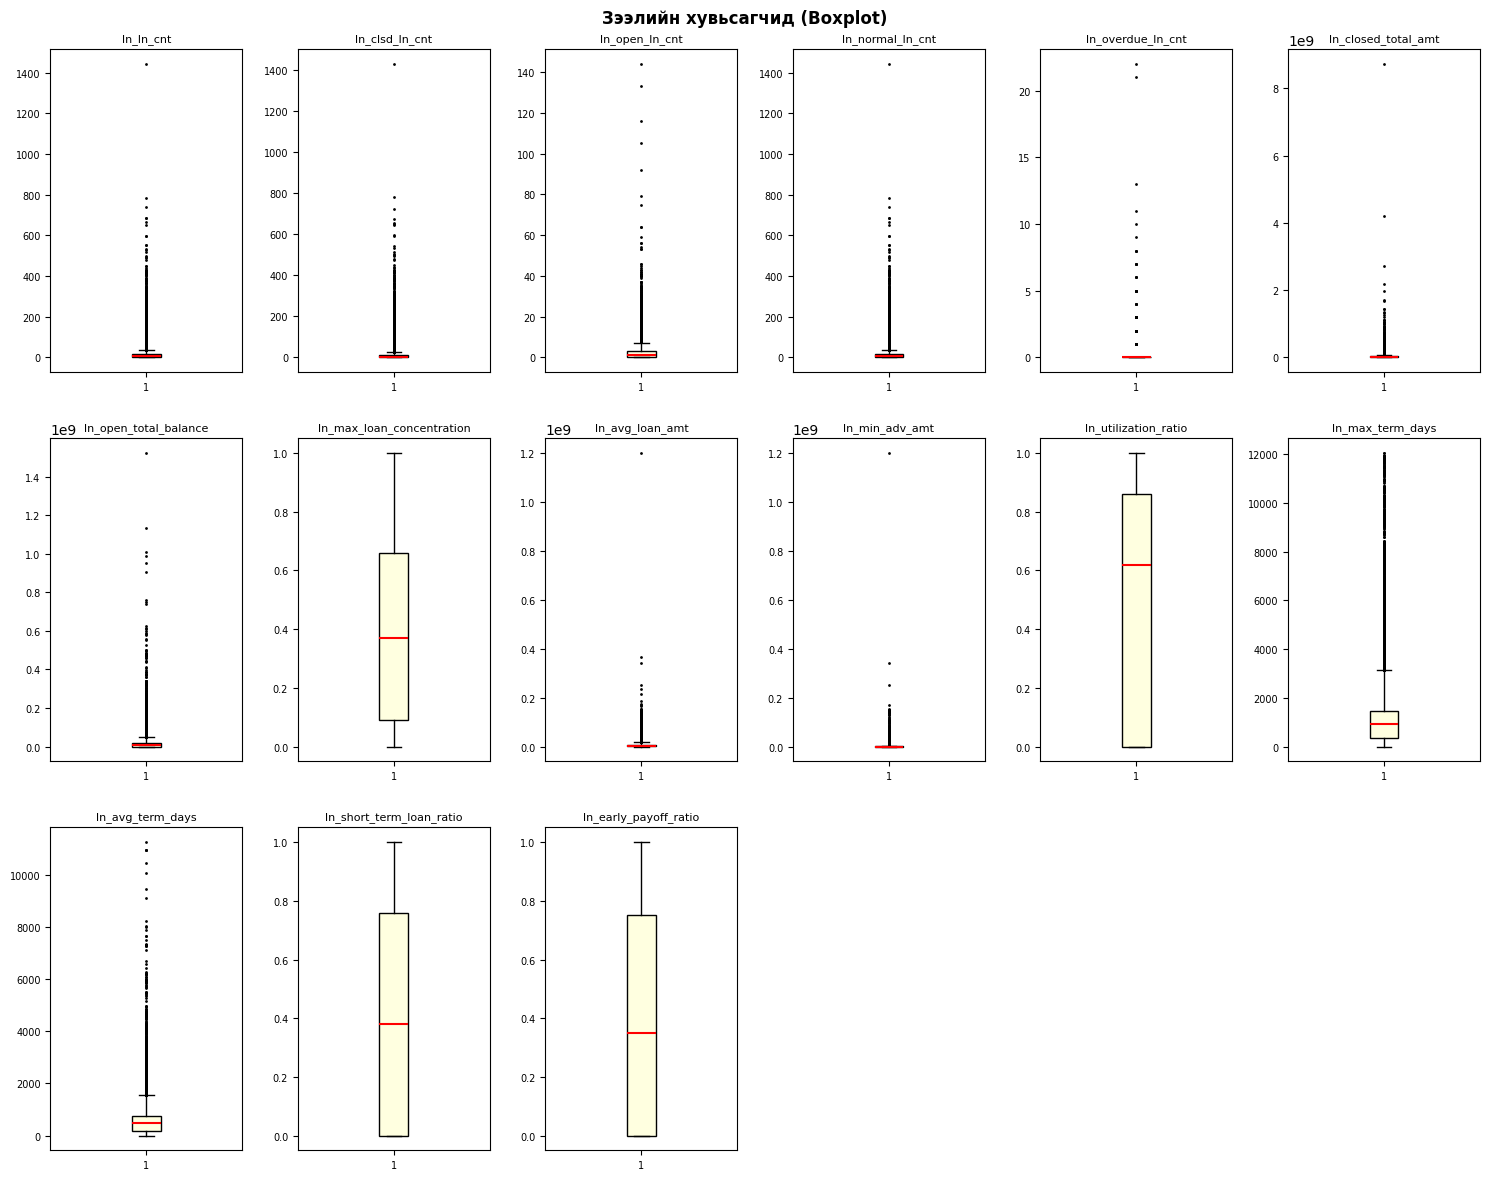

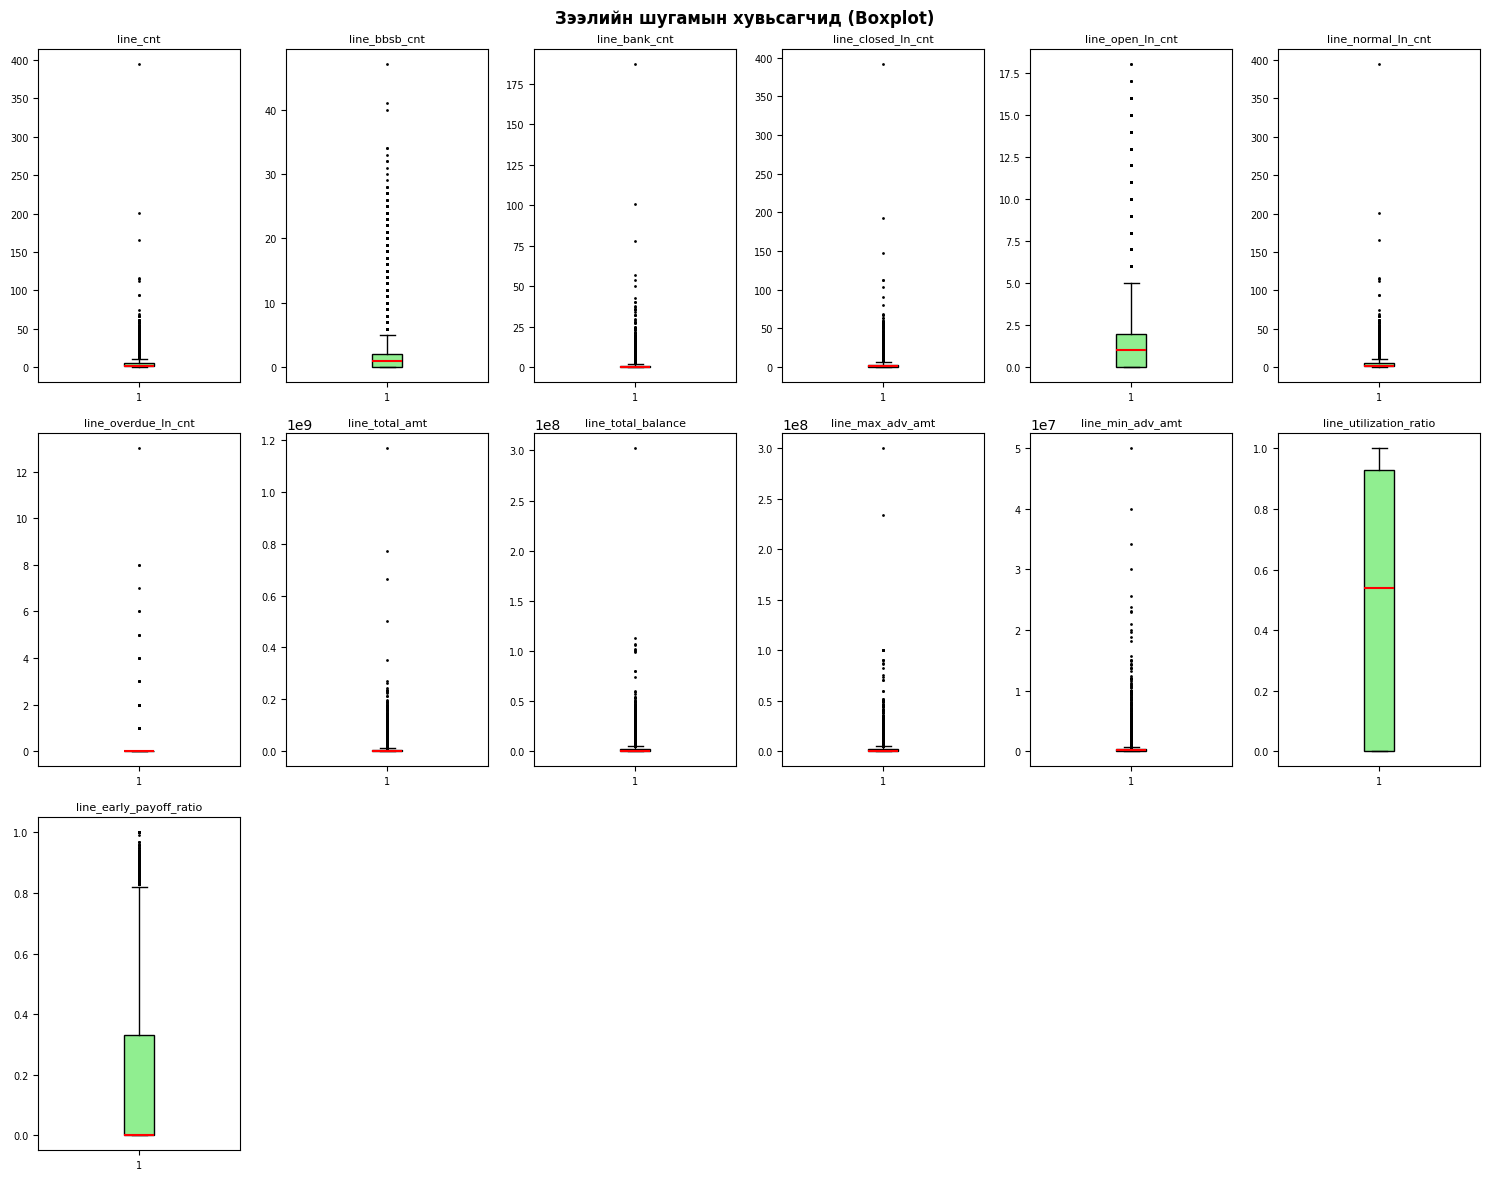

In [13]:
salary_cols = [c for c in num_cols if 'salary' in c]
loan_cols   = [c for c in num_cols if c.startswith('ln_')]
line_cols   = [c for c in num_cols if c.startswith('line_')]

def plot_boxplots(cols, title, color='lightblue'):
    if not cols: return
    n = len(cols)
    ncb = min(n, 6)
    nrb = (n + ncb - 1) // ncb
    fig, axes = plt.subplots(nrb, ncb, figsize=(max(14, ncb*2.5), nrb*4))
    axes_flat = [axes] if n == 1 else axes.flatten()
    for ax, col in zip(axes_flat, cols):
        ax.boxplot(df1[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor=color),
                   medianprops=dict(color='red', linewidth=1.5),
                   flierprops=dict(marker='.', markersize=2))
        ax.set_title(col, fontsize=8)
        ax.tick_params(labelsize=7)
    for j in range(len(cols), len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_boxplots(salary_cols, 'Цалингийн хувьсагчид (Boxplot)', color='lightblue')
plot_boxplots(loan_cols,   'Зээлийн хувьсагчид (Boxplot)',   color='lightyellow')
plot_boxplots(line_cols,   'Зээлийн шугамын хувьсагчид (Boxplot)', color='lightgreen')

### 2. Зорилтот хувьсагчийн шинжилгээ (Target Analysis)

,Нийт,Хоосон,Муу (1),Сайн (0),Bad rate %
15+,57127.0,0.0,12220.0,44907.0,21.39
30+,57127.0,0.0,8111.0,49016.0,14.20
before_first_close_30+,57127.0,0.0,2832.0,54295.0,4.96


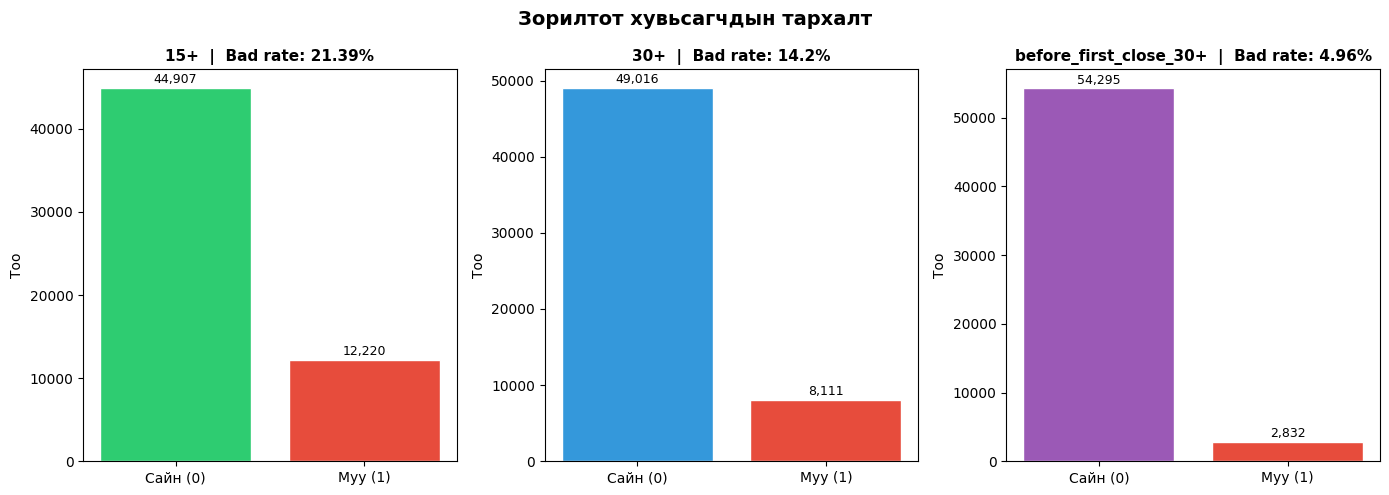

In [14]:
# Bad rate хүснэгт
bad_rates = {}
for t in target_cols:
    if t in df1.columns:
        total = int(df1[t].notna().sum())
        bad   = int(df1[t].sum())
        bad_rates[t] = {
            'Нийт': total,
            'Хоосон': int(df1[t].isna().sum()),
            'Муу (1)': bad,
            'Сайн (0)': total - bad,
            'Bad rate %': round(bad / total * 100, 2)
        }
display(pd.DataFrame(bad_rates).T)

# Bar chart
fig, axes = plt.subplots(1, len(target_cols), figsize=(14, 5))
palette = [['#2ecc71','#e74c3c'], ['#3498db','#e74c3c'], ['#9b59b6','#e74c3c']]
for ax, t, c in zip(axes, target_cols, palette):
    if t not in df1.columns: continue
    vals = df1[t].value_counts().sort_index()
    ax.bar(['Сайн (0)', 'Муу (1)'], vals.values, color=c, edgecolor='white')
    ax.set_title(f'{t}  |  Bad rate: {bad_rates[t]["Bad rate %"]}%', fontsize=11, fontweight='bold')
    ax.set_ylabel('Тоо')
    for bar, v in zip(ax.patches, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Зорилтот хувьсагчдын тархалт', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

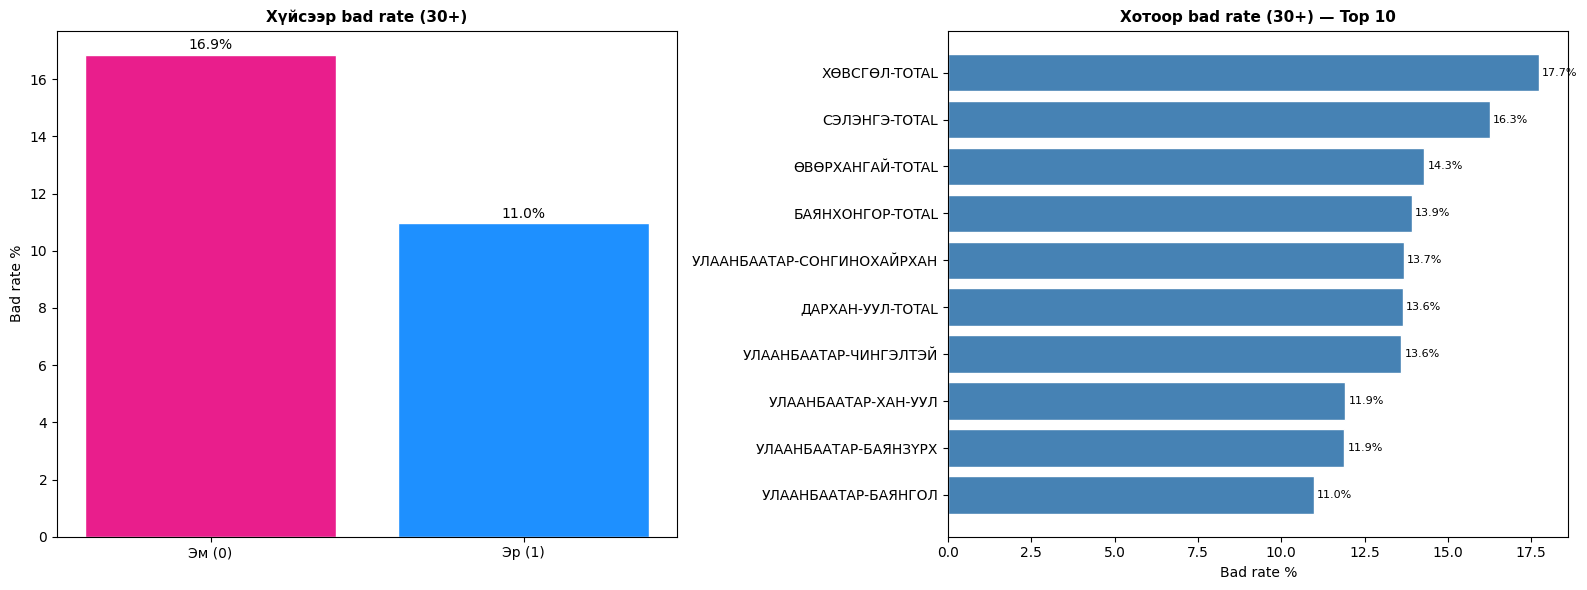

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Хүйсээр
if 'gender' in df1.columns and '30+' in df1.columns:
    gen_br = df1.groupby('gender')['30+'].mean() * 100
    gen_br.index = gen_br.index.map({0: 'Эм (0)', 1: 'Эр (1)'})
    axes[0].bar(gen_br.index, gen_br.values, color=['#e91e8c','#1e90ff'], edgecolor='white')
    axes[0].set_title('Хүйсээр bad rate (30+)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Bad rate %')
    for bar, v in zip(axes[0].patches, gen_br.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                     f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

# Хотоор (Top 10)
if 'city_name' in df1.columns and '30+' in df1.columns:
    top_cities = df1['city_name'].value_counts().head(10).index
    city_br = df1[df1['city_name'].isin(top_cities)].groupby('city_name')['30+'].mean() * 100
    city_br = city_br.sort_values()
    axes[1].barh(city_br.index, city_br.values, color='steelblue', edgecolor='white')
    axes[1].set_title('Хотоор bad rate (30+) — Top 10', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Bad rate %')
    for bar, v in zip(axes[1].patches, city_br.values):
        axes[1].text(v+0.1, bar.get_y()+bar.get_height()/2,
                     f'{v:.1f}%', ha='left', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 3. Корреляцийн матриц

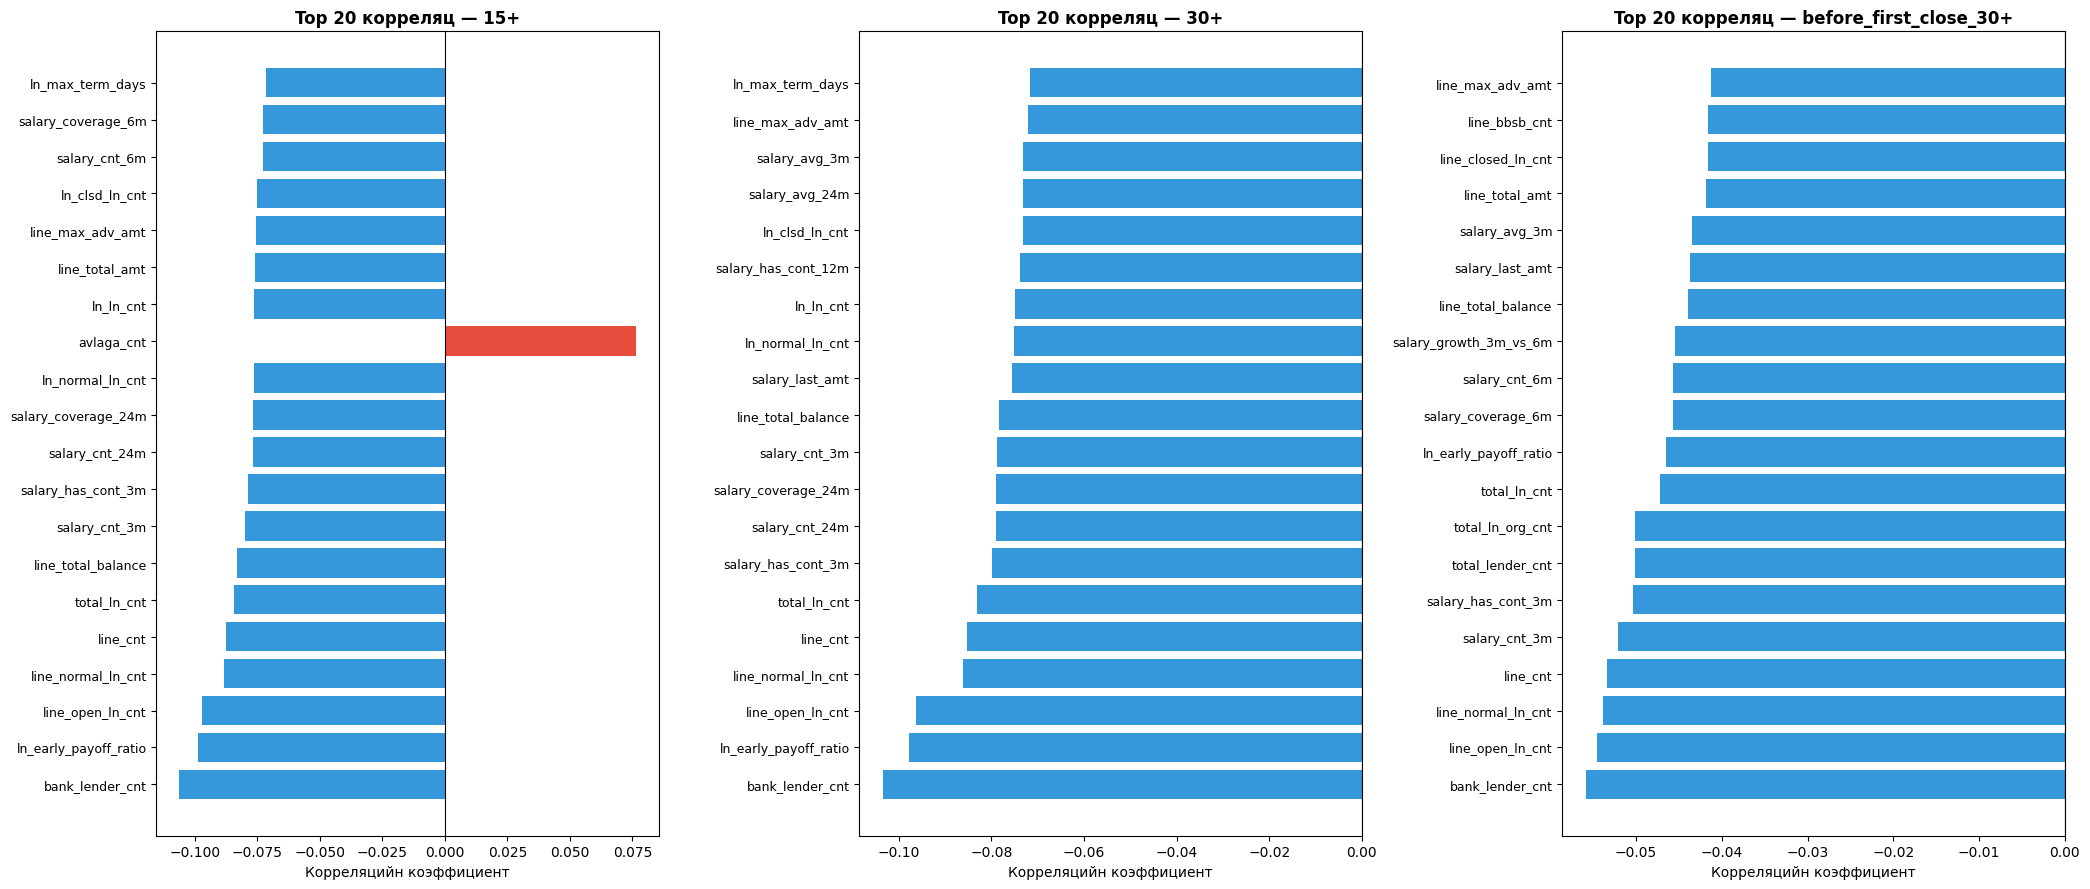

In [16]:
existing_targets = [t for t in target_cols if t in df1.columns]
corr_all = df1[num_cols + existing_targets].corr()

fig, axes = plt.subplots(1, len(existing_targets), figsize=(7*len(existing_targets), 9))
if len(existing_targets) == 1: axes = [axes]

for ax, t in zip(axes, existing_targets):
    top_corr = corr_all[t].drop(existing_targets).abs().sort_values(ascending=False).head(20)
    vals = corr_all[t].drop(existing_targets).loc[top_corr.index]
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in vals.values]
    ax.barh(range(len(vals)), vals.values, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=9)
    ax.set_title(f'Top 20 корреляц — {t}', fontsize=12, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Корреляцийн коэффициент')
plt.tight_layout()
plt.show()

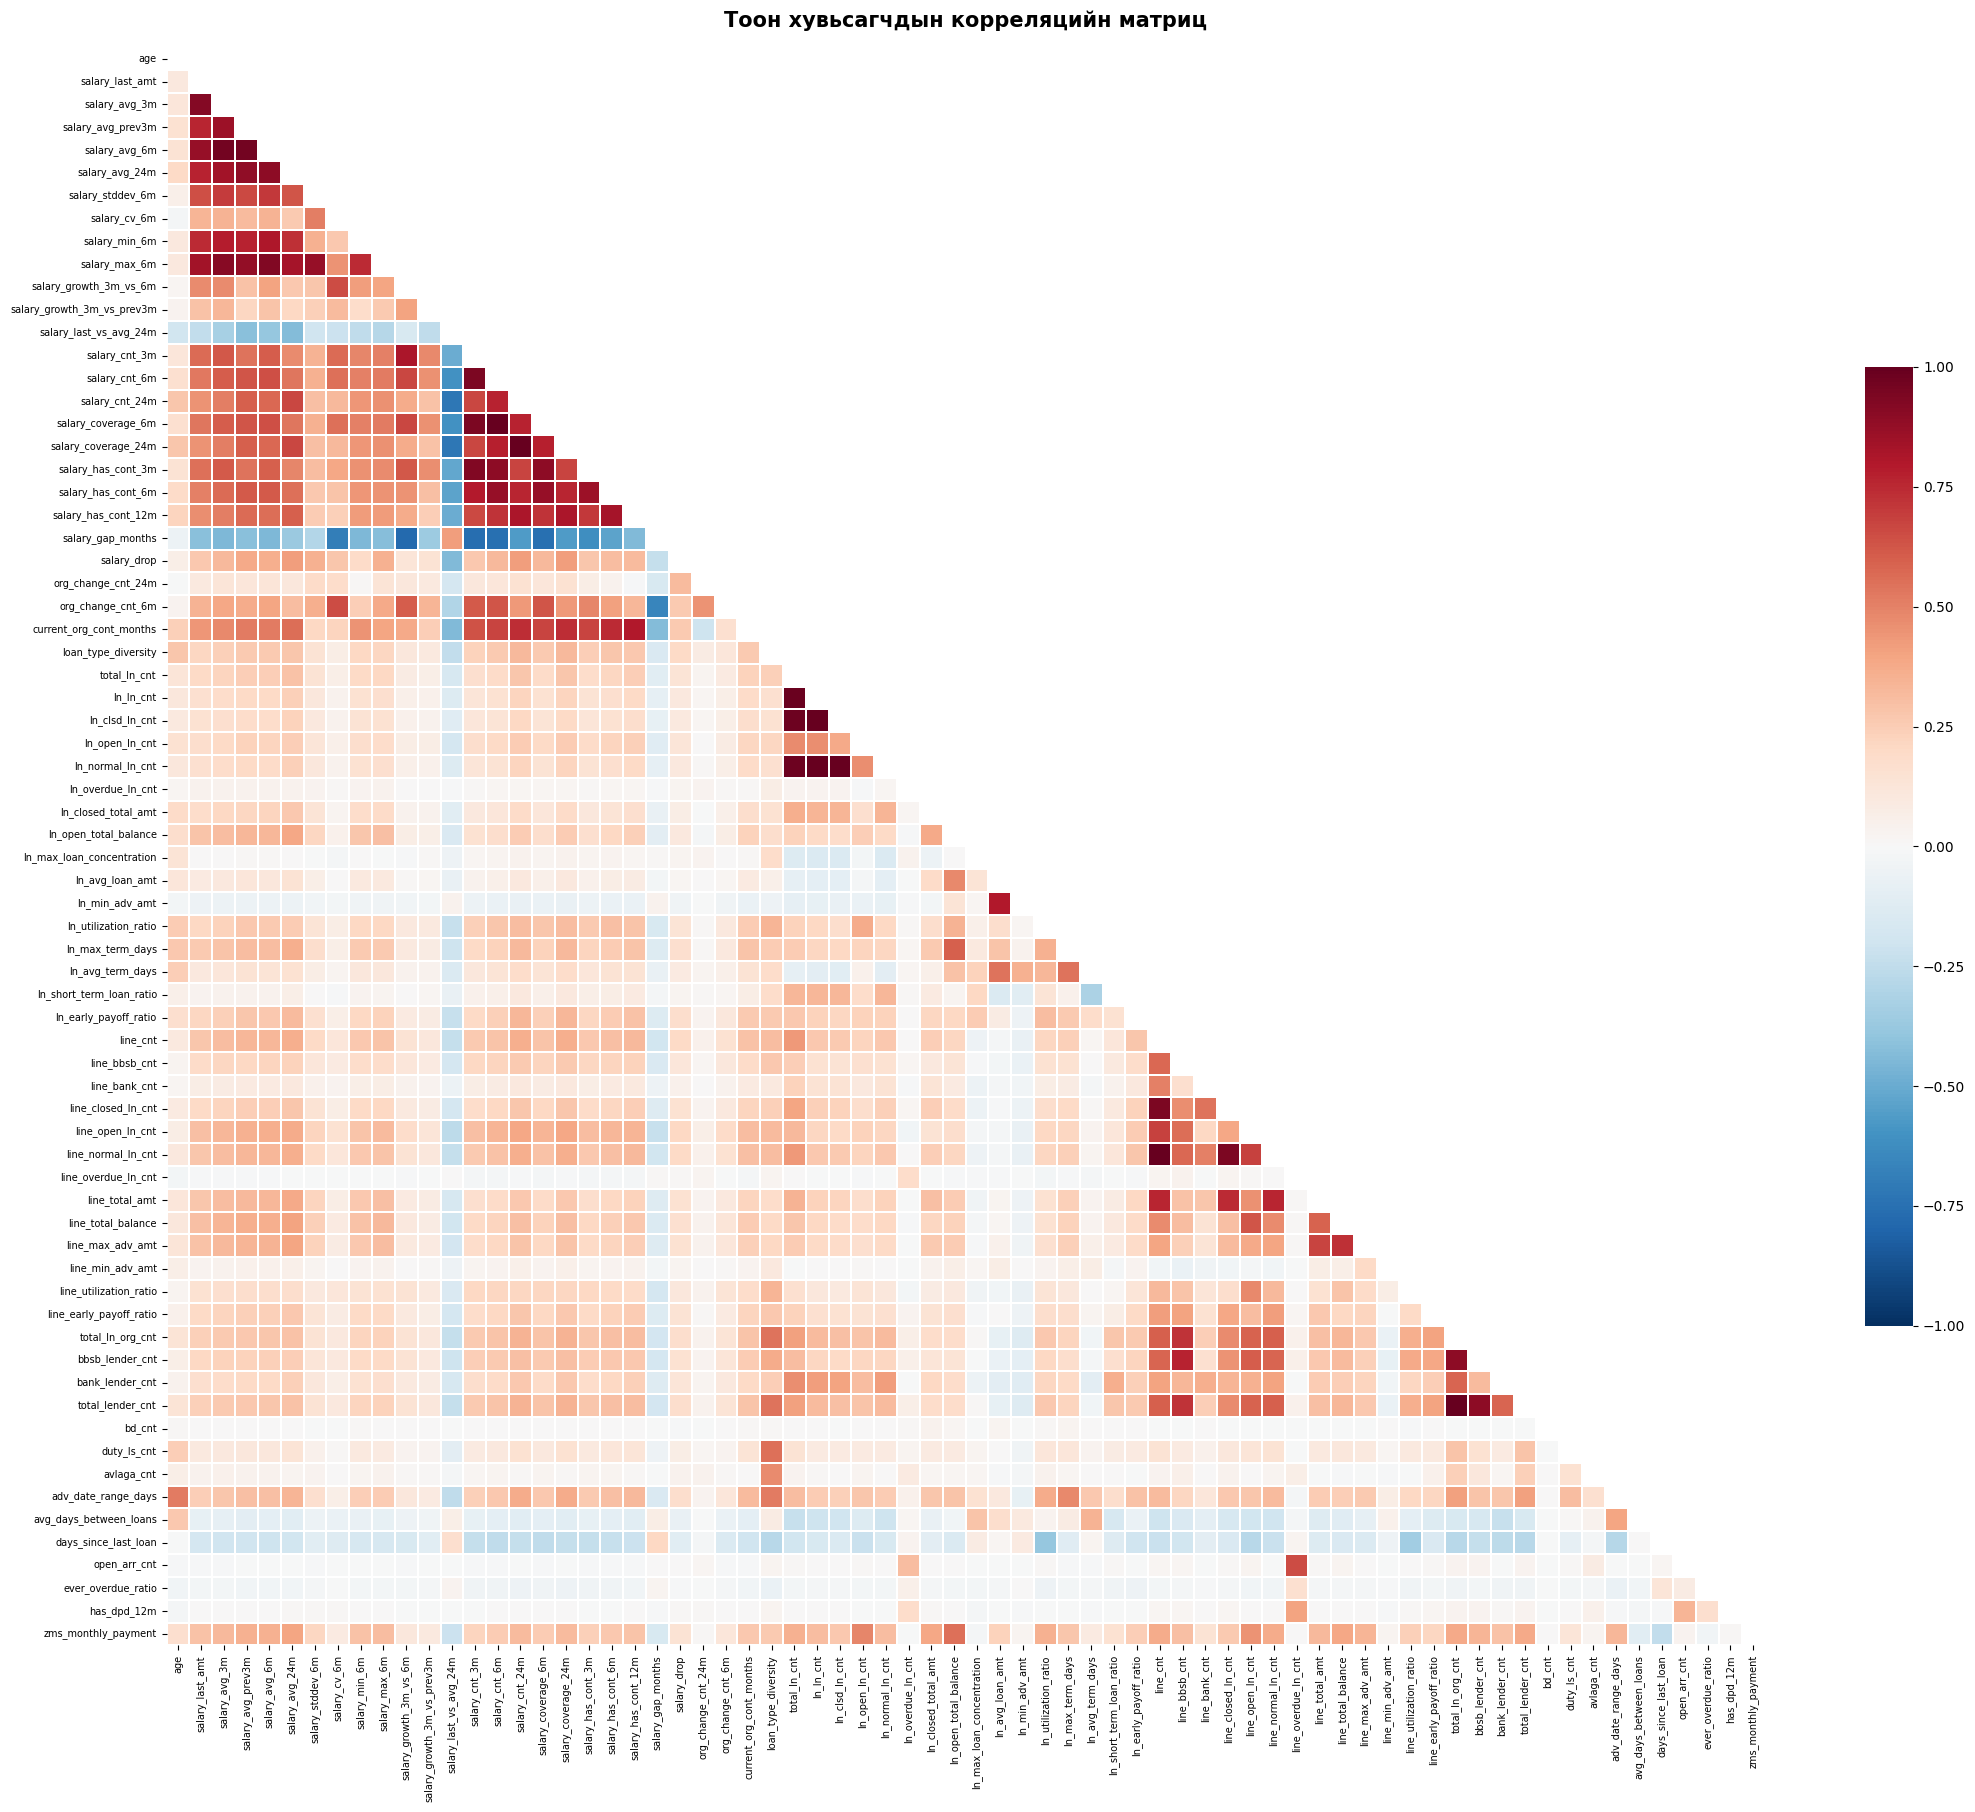

In [17]:
corr_matrix = df1[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True,
            linewidths=0.3, cbar_kws={'shrink': 0.6},
            annot=False, ax=ax)
ax.set_title('Тоон хувьсагчдын корреляцийн матриц', fontsize=15, fontweight='bold', pad=15)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()